In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import os
import json

from matplotlib import colors

import pandas as pd

import torch

In [2]:
def calculate_f(latitude: float):
    omega = 2 * np.pi / 24 / 60 / 60
    return 2 * omega * np.sin(np.pi * latitude / 180)

In [3]:
def calculate_T(latitude: float):
    return 2 * np.pi / calculate_f(latitude)

In [14]:
mean_vals = False

data_directory = '../m_star_dataset'
dataset_name = 'ePBL_paper_validation_2283_corrected'

method = "raw"

M_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_M.nc'))
bl_tke_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_tke_bl.nc'))
SS_profile_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_S2_sigma_{method}.nc'))
NN_profile_data = xr.open_dataset(os.path.join(data_directory, f'{dataset_name}_N2_sigma_{method}.nc'))

with open(os.path.join(data_directory, f'{dataset_name}_training_set_cases.json'), 'r') as file:
    gotm_case_dict = json.load(file)

In [15]:
rho0 = 1027
g = 9.81
alpha = 2e-4
cp = 4e3

heat_fluxes = np.array([case['heat_flux'] for case in gotm_case_dict.values()])
coriolis_freqs = np.array([calculate_f(case['lat']) for case in gotm_case_dict.values()])
u_stars = np.array([(case['tx'] / rho0) ** 0.5 for case in gotm_case_dict.values()])
taus = np.array([case['tx'] for case in gotm_case_dict.values()])

taus_mask = np.where(taus > 0.005)

Bs = g * alpha * heat_fluxes / (rho0 * cp)

n_cases, t_timesteps = M_data.M[taus_mask].values[:,2:].shape

Ms = M_data.M[taus_mask].values[:,2:].flatten()
tke_bls = -bl_tke_data.bl[taus_mask].values[:,2:].flatten()

coriolis_freqs = np.repeat(coriolis_freqs, t_timesteps)
u_stars = np.repeat(u_stars, t_timesteps)
taus = np.repeat(taus, t_timesteps)
Bs = np.repeat(Bs, t_timesteps)

In [16]:
t_timesteps

431

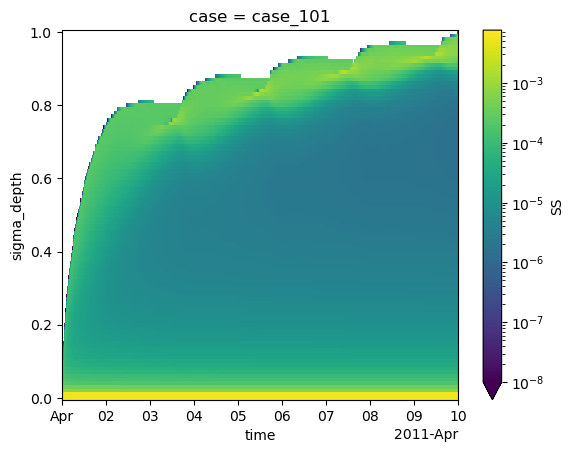

In [17]:
SS_profile_data.SS.T.isel(case=100).plot(norm=colors.LogNorm(vmin=1e-8))

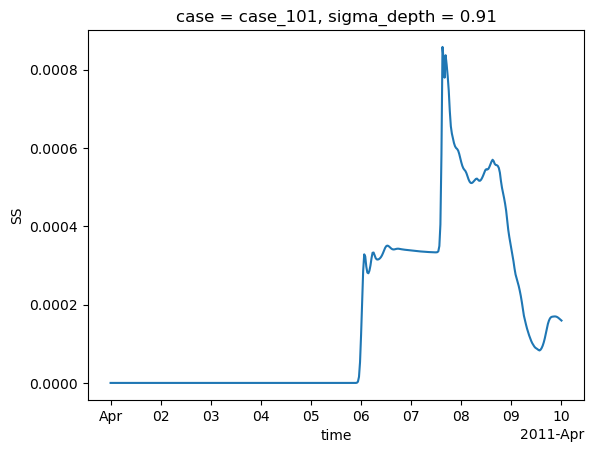

In [22]:
SS_profile_data.SS.T.isel(case=100).isel(sigma_depth=-10).plot()

In [75]:
sigma_depth = SS_profile_data.sigma_depth.values
SS_profiles = {f"SS_sig_{sigma_depth[i]:.2f}": SS_profile_data.SS[taus_mask].values[:,2:,i].flatten() for i in range(len(sigma_depth))}

In [76]:
sigma_depth = NN_profile_data.sigma_depth.values
NN_profiles = {f"NN_sig_{sigma_depth[i]:.2f}": NN_profile_data.NN[taus_mask].values[:,2:,i].flatten() for i in range(len(sigma_depth))}

In [77]:
data_dict = {"M": Ms, "bl_tke": tke_bls}

In [78]:
data_dict.update(SS_profiles)
data_dict.update(NN_profiles)

In [79]:
# make sure no std = 0 -> not possible to normalize

data_dict_cleared = data_dict.copy()

for key, value in data_dict.items():
    if np.std(value) == 0.:
        data_dict_cleared.pop(key)
    else:
        pass

In [80]:
df = pd.DataFrame(data_dict_cleared)
df.to_csv(os.path.join(data_directory, f'{dataset_name}_features_and_targets_101sig_even_{method}.csv'), index=False)

In [81]:
df

,M,bl_tke,SS_sig_0.00,SS_sig_0.01,SS_sig_0.02,SS_sig_0.03,SS_sig_0.04,SS_sig_0.05,SS_sig_0.06,SS_sig_0.07,...,NN_sig_0.91,NN_sig_0.92,NN_sig_0.93,NN_sig_0.94,NN_sig_0.95,NN_sig_0.96,NN_sig_0.97,NN_sig_0.98,NN_sig_0.99,NN_sig_1.00
0,2.877826e-07,15.084186,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.648858e-07,0.000003,0.000004,0.000006,0.000009,0.000013,0.000014,0.000014,0.000011,0.000011
1,6.135767e-07,20.866898,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.798133e-06,0.000005,0.000006,0.000008,0.000012,0.000016,0.000016,0.000015,0.000011,0.000011
2,8.995112e-07,24.994547,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,3.686584e-06,0.000006,0.000007,0.000010,0.000014,0.000018,0.000017,0.000016,0.000012,0.000011
3,1.145512e-06,28.995445,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,5.015214e-06,0.000008,0.000011,0.000014,0.000017,0.000018,0.000017,0.000016,0.000012,0.000011
4,1.355858e-06,32.954956,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,7.601996e-06,0.000013,0.000015,0.000017,0.000017,0.000017,0.000017,0.000015,0.000011,0.000011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93091,5.208164e-06,89.996323,0.000000,0.007192,0.007192,0.001917,0.000855,0.000483,0.000483,0.000311,...,8.202499e-06,0.000010,0.000013,0.000017,0.000027,0.000027,0.000056,0.000302,0.001995,0.000707
93092,5.192424e-06,89.998123,0.000000,0.007192,0.007192,0.001917,0.000855,0.000483,0.000483,0.000311,...,8.101687e-06,0.000010,0.000012,0.000017,0.000026,0.000026,0.000053,0.000273,0.001939,0.000793
93093,5.180957e-06,89.999413,0.000000,0.007192,0.007192,0.001917,0.000855,0.000483,0.000483,0.000311,...,7.991214e-06,0.000010,0.000012,0.000017,0.000025,0.000025,0.000049,0.000241,0.001896,0.000869
93094,5.176315e-06,90.544380,0.007192,0.007192,0.001917,0.000855,0.000483,0.000311,0.000311,0.000218,...,9.508136e-06,0.000012,0.000016,0.000024,0.000046,0.000046,0.000209,0.001862,0.000930,0.000082
